# Intelligent Agents: Reflex-Based Agents for GridHunt

Student Name: [Add your name]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]

## Learning Outcomes

* Apply core AI concepts by implementing the agent function for a simple and model-based reflex agents that respond to environmental percepts.
* Practice how the environment and the agent function interact.
* Analyze agent performance through controlled experiments across different environment configurations.

## Instructions

Total Points: Undergrads 10

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook.
### AI Use

Here are some guidelines that will make it easier for you:

* __Don't:__ Rely on AI auto completion. You will waste a lot of time trying to figure out how the suggested code relates to what we do in class. Turn off AI code completion (e.g., Copilot) in your IDE.
* __Don't:__ Do not submit code/text that you do not understand or have not checked to make sure that it is complete and correct.
* __Do:__ Use AI for debugging and letting it explain code and concepts from class.

## Introduction

![GridHunt Image](gridhunt.png)

Gridhunt is a small educational game that helps you practice implementing simple agent functions. It is a modified Python reimplementation of Gridhunt2. 

The objective of gridhunt is to implement an intelligent agent, the hunter, who can catch a monster faster than all other hunters. Gridhunt uses a $n \times n$ arena consisting of a grid of tiles. Gridhunt is a turn-based game, and the hunter and the monster move on this grid. A hunter catches the monster if she/he moves on the same square the monster currently occupies. If the monster survives the maximum number of steps for the game, then the monster wins.

## PEAS Description of Gridhunt

__Performance Measure:__ The performance is measured as the number of steps the hunter uses to catch the monster. Catching the monster means to be on the same square.

__Environment:__ An arena with $n \times n$ squares. At the beginning the monster and the hunter are randomly placed in the arena environment. The hunter and the monster
    can move around, but cannot leave the arena.

__Actuators:__ The agent can move to an adjacent square using actions "north", "east", "west", and "south", or teleport which will move the agent 
    to a random square in the arena.

__Sensors:__ The agent can always see its location in the arena but only gets the monster location when it stops and listens.

## The Arena Environment

The environment manages the location of the agents (hunter and monster). It initially places them in a random location and then provides them in every step with percepts (the location of the hunter and the monster) and asks them for their action. 

__A Note on positions:__
The arena is implemented as an array with row and column indices representing the position.
Positions are stored in a numpy array where `pos[0]` is the row index and `pos[1]` is the column index in the arena. North means up in this array, that is the row index gets smaller when going north. Remember indices in Python start with 0 and go to `n-1`.

In [4]:
import numpy as np
from IPython.display import clear_output
from time import sleep

def arena_environment(hunter_agent_function, 
                      monster_agent_function, 
                      n = 30, max_steps = 100, 
                      visualize = False, animation = False):
    """
    Simulate an arena where a hunter agent tries to catch a monster agent.

    Parameters:
    hunter_agent_function (function): A function that takes the current positions of the hunter and monster
                                      and returns the next move for the hunter ('north', 'east', 'west', 'south', 'teleport').
    monster_agent_function (function): A function that takes the current positions of the hunter and monster
                                       and returns the next move for the monster (or 'stay' to remain in place).
    n (int): The size of the arena (n x n grid).
    max_steps (int): The maximum number of steps to simulate.
    visualize (bool): Whether to visualize the arena.
    animation (bool): Whether to animate the visualization with a delay.

    Returns:
    int: The number of steps taken for the hunter to catch the monster or np.nan (not a number) if not caught.
    """
    
    # Initialize positions
    monster_pos = np.random.randint(0, n-1, size=2)
    hunter_pos = np.random.randint(0, n-1, size=2)
    
    def move(action, position):
        """calculate new position for the agent."""
        if action == 'north':
            position[0] -= 1
        elif action == 'south':
            position[0] += 1
        elif action == 'west':
            position[1] -= 1
        elif action == 'east':
            position[1] += 1
        else:
            raise ValueError("Invalid action.")
        
        # Ensure position stays within bounds
        position = np.clip(position, 0, n-1)
        return position

    def print_arena():

        if animation:
            sleep(1)
            clear_output(wait=True)
        print(f"Step {step+1}: Hunter is at '{hunter_pos}'; Monster is at '{monster_pos}'")
        arena = np.full((n, n), '.', dtype=str)
        arena[monster_pos[0], monster_pos[1]] = 'M'
        arena[hunter_pos[0], hunter_pos[1]] = 'H'
        if np.array_equal(hunter_pos, monster_pos):
            arena[monster_pos[0], monster_pos[1]] = '*'
        print("\n".join("".join(row) for row in arena))

    # run the environment
    hunter_action = None  # Initialize hunter_action to None for the first step
    for step in range(max_steps):
        if visualize:
            print_arena()
        
        # Check if hunter has caught the monster
        if np.array_equal(hunter_pos, monster_pos):
            if visualize:
                print(f"Hunter caught the monster in {step} steps!")
            return step
        
        # Get next move from monster agent function
        monster_action = monster_agent_function(hunter_pos, monster_pos)
        
        if monster_action != 'stay':
            monster_pos = move(monster_action, monster_pos)

        # Get next move from hunter agent function. The monster's position is only provided 
        # if the hunter chose 'listen' as the previous action.
        if hunter_action == 'listen':
            monster_pos_instrument = monster_pos
        else: 
            monster_pos_instrument = None
        
        hunter_action = hunter_agent_function(hunter_pos, monster_pos_instrument)
        
        if hunter_action == 'listen':
            pass
        elif hunter_action == 'teleport':
            hunter_pos = np.random.randint(0, n-1, size=2)
        else:
            hunter_pos = move(hunter_action, hunter_pos)
    
        # print the agents' actions
        if visualize:
            print(f"Hunter chose action '{hunter_action}'")
            print(f"Monster chose action '{monster_action}'")
            print("\n")

    # the hunter failed to catch the monster within max_steps
    if visualize:
        print(f"Hunter failed to catch the monster in {max_steps} steps.")
    
    return np.nan

I implement the monster here as a simple agent that moves around randomly, but mostly stays in its place. You can use AI to get a detailed explanation of how the following code works.

In [5]:
monster_actions = ["north", "east", "west", "south", "stay"]

def monster_agent_function_simple(hunter_pos, monster_pos):
    return np.random.choice(monster_actions, p=[0.125, 0.125, 0.125, 0.125, 0.5])

# The Hunter Agent

Your job is to implement a simple-reflex hunter agent that can catch the monster. Remember, your agent is implemented as an agent function that get percepts and needs to return a valid action. The actions are: 

In [6]:
actions = ["north", "east", "west", "south", "teleport", "listen"]

## A Simple Example Implementation

Here is a very simple hunter that just runs around randomly and hopes that it bumps into the monster. 

In [7]:
def simple_randomized_hunter_agent_function(hunter_location, monster_location):
    return np.random.choice(actions)

Ask the agent for an action.

In [8]:
simple_randomized_hunter_agent_function([0,0], None)

np.str_('listen')

## Experimenting With the Agent

We can place the monster and the hunter into the environment and run a simulation by calling the environment function.

In [9]:
arena_environment(simple_randomized_hunter_agent_function, 
                  monster_agent_function_simple, 
                  n=5, max_steps=10, visualize=True, animation=False)

Step 1: Hunter is at '[3 3]'; Monster is at '[3 0]'
.....
.....
.....
M..H.
.....
Hunter chose action 'listen'
Monster chose action 'stay'


Step 2: Hunter is at '[3 3]'; Monster is at '[3 0]'
.....
.....
.....
M..H.
.....
Hunter chose action 'listen'
Monster chose action 'stay'


Step 3: Hunter is at '[3 3]'; Monster is at '[3 0]'
.....
.....
.....
M..H.
.....
Hunter chose action 'west'
Monster chose action 'stay'


Step 4: Hunter is at '[3 2]'; Monster is at '[3 0]'
.....
.....
.....
M.H..
.....
Hunter chose action 'west'
Monster chose action 'north'


Step 5: Hunter is at '[3 1]'; Monster is at '[2 0]'
.....
.....
M....
.H...
.....
Hunter chose action 'west'
Monster chose action 'stay'


Step 6: Hunter is at '[3 0]'; Monster is at '[2 0]'
.....
.....
M....
H....
.....
Hunter chose action 'listen'
Monster chose action 'stay'


Step 7: Hunter is at '[3 0]'; Monster is at '[2 0]'
.....
.....
M....
H....
.....
Hunter chose action 'north'
Monster chose action 'north'


Step 8: Hunter is 

nan

**Note for VS Code:** View as scrollable element to see the complete output.

Well, this was one run, maybe it was just good or bad luck this time!

Let's run an experiment with 100 runs in a $10 \times 10$ arena.  

In [10]:
steps = [arena_environment(simple_randomized_hunter_agent_function, monster_agent_function_simple, n=10, max_steps=100, visualize=False) for _ in range(100)] 
print(steps)

[54, nan, 64, 55, nan, 15, 5, nan, nan, nan, nan, 31, nan, 5, nan, nan, 3, 52, nan, nan, 83, 88, 98, 19, nan, nan, 93, nan, 88, nan, 94, nan, 15, 6, nan, 16, 63, 48, 20, nan, 96, nan, nan, nan, nan, 41, nan, 48, nan, 33, 41, 8, 21, nan, nan, nan, nan, nan, 16, 32, 38, nan, nan, nan, 16, 53, 9, 35, 71, 57, 30, 59, 33, nan, 10, 78, 22, nan, nan, nan, 53, 0, 34, nan, 11, 8, nan, nan, 14, 36, 89, 75, 33, 4, nan, nan, nan, 16, 66, 65]


We just got a list with the number of steps to catch the monster for 100 simulation runs.
Let's analysis the results. `nan` means that the hunter was not able to catch the monster. How many times did that happen? To answer how well the hunter did when it caught the monster, we just average the numbers that are not `nan`. 

In [11]:
print (f"Hunter failed {np.sum(np.isnan(steps))} times.")
print (f"Average steps to catch the monster over {np.sum(~np.isnan(steps))} successful runs: {round(np.nanmean(steps), 2)}")

Hunter failed 42 times.
Average steps to catch the monster over 58 successful runs: 40.79


This in not a very good agent. You need to implement a better agent function.

# Your Agent Implementation [4 points]

Write a new hunter agent function that chases the monster. Copy the simple randomized hunter function from above and make it into a model-based reflex agent. It should use listen to get the monster's location and then move towards the monster. To do that it needs to remember the monster's location. This memory makes it model-based. Here is HOWTO: How to Store State Information in the Agent.

### Chiến lược: tác tử phản xạ dựa trên mô hình (model-based reflex)

**Vì sao cần trạng thái bên trong?** Môi trường chỉ đưa vị trí quái vật cho tác tử ở bước *ngay sau khi* tác tử chọn `listen`; ở các bước còn lại `monster_location = None`. Một tác tử phản xạ đơn giản (chỉ nhìn percept hiện tại) sẽ không biết phải đi đâu. Tác tử model-based lưu lại **mô hình** của thế giới: "quái vật đang ở đâu (theo lần nghe gần nhất)".

**Trạng thái bên trong**

| Biến | Ý nghĩa |
|---|---|
| `mem` | Vị trí quái vật ở lần `listen` gần nhất. Lưu **bản sao** `np.array(...)`, vì môi trường cập nhật mảng vị trí "tại chỗ"; nếu chỉ giữ tham chiếu thì `mem` sẽ bị đổi theo quái vật. |
| `since` | Số bước đã đi kể từ lần `listen` gần nhất (đo độ "cũ" của thông tin). |

**Luật hành động** (kiểm tra theo thứ tự):

1. Chưa có `mem` → `listen`.
2. *(chỉ bản có teleport)* Khoảng cách Manhattan từ thợ săn tới `mem` > `T` → `teleport`.
3. Đã tới vị trí `mem`, hoặc đã đi `k` bước kể từ lần nghe cuối → `listen` để làm mới mô hình (quái vật vẫn di chuyển).
4. Ngược lại → đi 1 bước về phía `mem`, theo trục còn lệch nhiều hơn. Mỗi bước như vậy giảm khoảng cách Manhattan đúng 1; đây là cách chọn hành động tham lam theo heuristic khoảng cách Manhattan (cùng ý tưởng greedy best-first trong slide Search).

**Tham số:** `k = 8` và `T = 0.4 × n` (kích thước đấu trường `n` do người thiết kế truyền vào khi tạo tác tử). Hai giá trị này được chọn dựa trên các thí nghiệm quét tham số ở bên dưới.


In [12]:
import numpy as np

def manhattan(a, b):
    """Khoảng cách Manhattan = số bước tối thiểu để đi từ a đến b trên lưới (4 hướng)."""
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def step_toward(hunter, target):
    """Đi 1 bước về phía target theo trục còn lệch NHIỀU hơn -> khoảng cách Manhattan giảm 1."""
    dr, dc = target[0] - hunter[0], target[1] - hunter[1]
    if abs(dr) >= abs(dc):
        return 'south' if dr > 0 else 'north'      # hàng lớn hơn -> đi xuống, nhỏ hơn -> đi lên
    return 'east' if dc > 0 else 'west'            # cột lớn hơn -> đi sang phải, nhỏ hơn -> sang trái

def make_model_based_hunter(k=8, teleport_threshold=None):
    """
    Tạo MỘT tác tử phản xạ dựa trên mô hình (model-based reflex agent).

    k                  : sau tối đa k bước đi thì nghe lại (listen) để làm mới mô hình.
    teleport_threshold : nếu không None, teleport khi khoảng cách Manhattan tới vị trí đã nhớ > ngưỡng.

    Vì tác tử có trạng thái bên trong nên MỖI VÁN phải tạo một tác tử mới.
    """
    state = {'mem': None,     # vị trí quái vật ở lần listen gần nhất (mô hình của thế giới)
             'since': 0}      # số bước đã đi kể từ lần listen gần nhất

    def agent_function(hunter_location, monster_location):
        # (1) Vừa listen xong -> cập nhật mô hình. Phải COPY vì môi trường sửa mảng vị trí "tại chỗ".
        if monster_location is not None:
            state['mem'] = np.array(monster_location)
            state['since'] = 0

        # (2) Chưa biết gì về quái vật -> nghe.
        if state['mem'] is None:
            return 'listen'

        d = manhattan(hunter_location, state['mem'])

        # (3) Quá xa -> teleport (bỏ tiến độ cũ, hy vọng rơi vào chỗ gần quái vật hơn).
        if teleport_threshold is not None and d > teleport_threshold:
            return 'teleport'

        # (4) Đã tới nơi đã nhớ hoặc thông tin đã cũ -> nghe lại.
        if d == 0 or state['since'] >= k:
            return 'listen'

        # (5) Ngược lại đi 1 bước về phía vị trí đã nhớ.
        state['since'] += 1
        return step_toward(hunter_location, state['mem'])

    return agent_function

In [13]:
# Kiểm tra nhanh giao diện hàm: (vị trí thợ săn, vị trí quái vật hoặc None) -> hành động
agent = make_model_based_hunter(k=3)
print(agent([0, 0], None))       # chưa biết quái vật ở đâu       -> listen
print(agent([0, 0], [4, 1]))     # vừa nghe: quái vật ở hàng 4    -> south (trục lệch nhiều hơn)
print(agent([1, 0], None))       # dùng lại vị trí đã nhớ         -> south
print(agent([2, 0], None))       # tiếp tục                       -> south

listen
south
south
south


# Your Experiments [2 points]

Copy the simulation code from above and run experiments with your agent. 
Experiment with larger arenas of at least size $30 \times 30$.

### Thiết lập thí nghiệm

* Mỗi cấu hình chạy **1000 ván** (đề yêu cầu ít nhất 100) để số trung bình ổn định; mỗi ván giới hạn **100 bước**, đặt `np.random.seed(42)` để chạy lại cho kết quả giống nhau.
* Mỗi ván dùng **một tác tử mới** (do tác tử có trạng thái bên trong).
* **Tỷ lệ bắt được** = % ván bắt được quái vật trong 100 bước. **Số bước TB** chỉ tính trên các ván bắt được (bỏ các ván `nan`).

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

RUNS = 1000        # số ván cho mỗi cấu hình
MAX_STEPS = 100    # giới hạn số bước mỗi ván

def run_experiment(agent_factory, n, runs=RUNS, max_steps=MAX_STEPS, seed=42):
    """Chạy `runs` ván; mỗi ván tạo một tác tử mới bằng agent_factory()."""
    np.random.seed(seed)
    steps = np.array([arena_environment(agent_factory(), monster_agent_function_simple,
                                        n=n, max_steps=max_steps) for _ in range(runs)], dtype=float)
    success = ~np.isnan(steps)
    return {'success_rate': 100 * success.mean(),
            'avg_steps': np.nanmean(steps) if success.any() else np.nan}

def make_agents(n, k=8, teleport_fraction=0.4):
    """Ba tác tử để so sánh trên đấu trường n×n."""
    return {
        'Ngẫu nhiên': lambda: simple_randomized_hunter_agent_function,
        'Model-based (không teleport)': lambda: make_model_based_hunter(k=k),
        'Model-based + teleport': lambda: make_model_based_hunter(
            k=k, teleport_threshold=round(teleport_fraction * n)),
    }

rows = []
for n in (10, 30):
    for name, factory in make_agents(n).items():
        r = run_experiment(factory, n)
        rows.append({'Đấu trường': f'{n}×{n}', 'Tác tử': name,
                     'Tỷ lệ bắt được (%)': round(r['success_rate'], 1),
                     'Số bước TB (các ván thành công)': round(r['avg_steps'], 2)})
results = pd.DataFrame(rows)
results

,Đấu trường,Tác tử,Tỷ lệ bắt được (%),Số bước TB (các ván thành công)
0,10×10,Ngẫu nhiên,50.8,42.13
1,10×10,Model-based (không teleport),100.0,9.37
2,10×10,Model-based + teleport,100.0,8.02
3,30×30,Ngẫu nhiên,6.2,54.85
4,30×30,Model-based (không teleport),100.0,24.35
5,30×30,Model-based + teleport,100.0,15.40


#### Chọn tham số `k` (bao lâu nghe lại một lần)


In [ ]:
ks = [1, 2, 4, 8, 16, 1000]     # k = 1000 nghĩa là gần như không nghe lại giữa đường
rows = []
for k in ks:
    row = {'k': k}
    for n in (10, 30):
        r = run_experiment(lambda: make_model_based_hunter(k=k), n)
        row[f'{n}x{n}: số bước TB'] = round(r['avg_steps'], 2)
        row[f'{n}x{n}: tỷ lệ bắt (%)'] = round(r['success_rate'], 1)
    rows.append(row)
pd.DataFrame(rows).set_index('k')

,10×10: số bước TB,10×10: tỷ lệ bắt (%),30×30: số bước TB,30×30: tỷ lệ bắt (%)
k,,,,
1,12.21,100.0,39.69,99.6
2,10.03,100.0,30.03,100.0
4,9.04,100.0,27.05,100.0
8,9.37,100.0,24.35,100.0
16,9.58,100.0,24.54,100.0
1000,9.58,100.0,25.96,100.0


**Nhận xét về `k`:**
* `k` nhỏ (1–2) tốn quá nhiều bước cho việc nghe: ở 30×30, `k = 1` cần **39.69** bước và còn có ván không bắt kịp (99.6%), vì cứ đi 1 bước lại mất 1 bước nghe.
* `k` rất lớn (1000, gần như không nghe lại giữa đường) dùng thông tin đã cũ nên chậm hơn: **25.96** bước ở 30×30.
* Vùng `k` từ 4 đến 16 cho kết quả gần như tương đương (10×10: 9.04–9.58 bước; 30×30: 24.35–27.05 bước). Chọn **k = 8** là hợp lý cho cả hai kích thước. Quái vật đứng yên 50% số bước nên vị trí đã nhớ "cũ" khá chậm; đó là lý do không cần nghe lại thường xuyên.

#### Teleport có lợi hay có hại? Quét ngưỡng teleport `T = f × n`

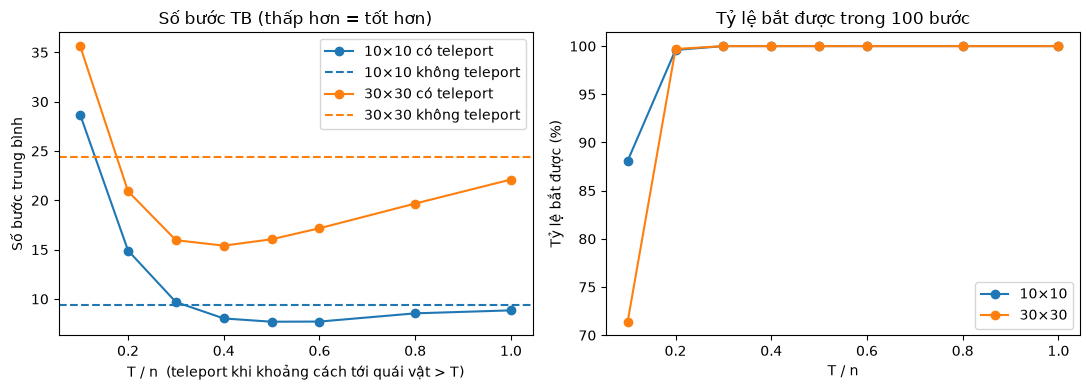

,Đấu trường,T/n,T,Số bước TB,Tỷ lệ bắt (%)
0,10×10,0.1,1,28.69,88.1
1,10×10,0.2,2,14.91,99.6
2,10×10,0.3,3,9.69,100.0
3,10×10,0.4,4,8.02,100.0
4,10×10,0.5,5,7.69,100.0
5,10×10,0.6,6,7.71,100.0
6,10×10,0.8,8,8.54,100.0
7,10×10,1.0,10,8.84,100.0
8,30×30,0.1,3,35.63,71.4
9,30×30,0.2,6,20.92,99.7


In [16]:
fractions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
tele_table = []
for n in (10, 30):
    base = run_experiment(lambda: make_model_based_hunter(k=8), n)
    avg, suc = [], []
    for f in fractions:
        r = run_experiment(lambda: make_model_based_hunter(k=8, teleport_threshold=round(f * n)), n)
        avg.append(r['avg_steps']); suc.append(r['success_rate'])
        tele_table.append({'Đấu trường': f'{n}×{n}', 'T/n': f, 'T': round(f * n),
                           'Số bước TB': round(r['avg_steps'], 2), 'Tỷ lệ bắt (%)': round(r['success_rate'], 1)})
    line, = axes[0].plot(fractions, avg, marker='o', label=f'{n}×{n} có teleport')
    axes[0].axhline(base['avg_steps'], ls='--', color=line.get_color(), label=f'{n}×{n} không teleport')
    axes[1].plot(fractions, suc, marker='o', label=f'{n}×{n}')
axes[0].set_xlabel('T / n  (teleport khi khoảng cách tới quái vật > T)'); axes[0].set_ylabel('Số bước trung bình')
axes[0].set_title('Số bước TB (thấp hơn = tốt hơn)'); axes[0].legend()
axes[1].set_xlabel('T / n'); axes[1].set_ylabel('Tỷ lệ bắt được (%)')
axes[1].set_title('Tỷ lệ bắt được trong 100 bước'); axes[1].legend()
plt.tight_layout(); plt.show()
pd.DataFrame(tele_table)

**Nhận xét về teleport** (đường nét đứt trong biểu đồ trái là tác tử không teleport):

* **Có lợi khi thợ săn ở xa quái vật.** Teleport tốn đúng 1 bước cho dù xa bao nhiêu, và đưa thợ săn tới một ô ngẫu nhiên. Khoảng cách trung bình giữa hai ô ngẫu nhiên chỉ khoảng 2n/3, nên nếu đang ở xa hơn mức đó thì "bốc lại" thường có lợi. Nhờ có mô hình (`mem`), tác tử tính được ngay khoảng cách mới mà không cần nghe lại; nếu vẫn xa thì teleport tiếp, giống như "thử lại cho tới khi rơi gần quái vật".
* **Ngưỡng tốt** nằm quanh `T ≈ 0.4–0.5·n` ở cả hai kích thước (ở 10×10, ngưỡng `T ≤ 0.3n` còn tệ hơn không teleport). Với `T = 0.4n`: 30×30 giảm từ **24.35 → 15.40** bước (**−37%**); 10×10 giảm từ **9.37 → 8.02** bước (**−14%**).
* **Có hại khi ngưỡng quá thấp**: tác tử teleport cả khi đã ở gần quái vật, bỏ phí tiến độ đã có và gần như thành đi ngẫu nhiên. Với `T = 0.1n`: 10×10 chỉ bắt được **88.1%** ván (28.69 bước), 30×30 chỉ **71.4%** (35.63 bước), tệ hơn cả khi không teleport.
* **Ngưỡng quá cao** (T = n) hầu như không kích hoạt, lợi ích thu hẹp lại (30×30: 22.11 bước).

#### Ảnh hưởng của kích thước đấu trường


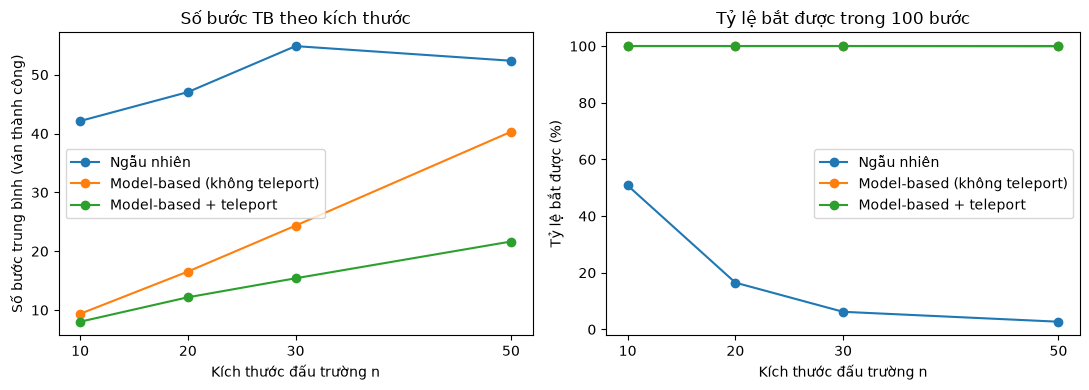

Tác tử,Ngẫu nhiên,Model-based (không teleport),Model-based + teleport
n,,,
10,42.13,9.37,8.02
20,47.04,16.54,12.18
30,54.85,24.35,15.40
50,52.37,40.30,21.65


In [17]:
sizes = [10, 20, 30, 50]
rows = []
for n in sizes:
    for name, factory in make_agents(n).items():
        r = run_experiment(factory, n)
        rows.append({'n': n, 'Tác tử': name, 'Số bước TB': r['avg_steps'], 'Tỷ lệ bắt (%)': r['success_rate']})
size_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, g in size_df.groupby('Tác tử', sort=False):
    axes[0].plot(g['n'], g['Số bước TB'], marker='o', label=name)
    axes[1].plot(g['n'], g['Tỷ lệ bắt (%)'], marker='o', label=name)
axes[0].set_xlabel('Kích thước đấu trường n'); axes[0].set_ylabel('Số bước trung bình (ván thành công)')
axes[0].set_title('Số bước TB theo kích thước'); axes[0].set_xticks(sizes); axes[0].legend(loc='center left')
axes[1].set_xlabel('Kích thước đấu trường n'); axes[1].set_ylabel('Tỷ lệ bắt được (%)')
axes[1].set_title('Tỷ lệ bắt được trong 100 bước'); axes[1].set_xticks(sizes); axes[1].legend()
plt.tight_layout(); plt.show()
size_df.pivot(index='n', columns='Tác tử', values='Số bước TB').round(2)[list(make_agents(10).keys())]

**Nhận xét về kích thước đấu trường:**
* **Tác tử ngẫu nhiên** sụp đổ nhanh: tỷ lệ bắt được giảm từ 50.8% (10×10) xuống 6.2% (30×30) và thấp hơn nữa ở 50×50. Số bước TB của nó nhìn có vẻ "ổn" nhưng chỉ tính trên các ván may mắn bắt được (thiên lệch), nên không nên so sánh cột này.
* **Model-based không teleport**: số bước TB tăng gần tuyến tính theo n (9.37 → 16.54 → 24.35 → 40.30 khi n = 10, 20, 30, 50; xấp xỉ 0.8n) vì quãng đường phải đi tỷ lệ với khoảng cách ban đầu. Tỷ lệ bắt vẫn 100%.
* **Model-based + teleport** tăng chậm hơn hẳn (8.02 → 12.18 → 15.40 → 21.65), nên **lợi thế của teleport càng lớn khi đấu trường càng rộng**: giảm 14% ở 10×10 nhưng 46% ở 50×50 (40.30 → 21.65).

## Your Conclusion [4 points] 

Discuss the following:

* What is your hunter's final strategy to choose actions. Why does it work well?
* Do you use teleportation. Why and in what situation? Why not?
* How does the arena size affects your hunter agent's performance?

 ### 1. Chiến lược chọn hành động và vì sao hiệu quả
 Thợ săn cuối cùng là tác tử **phản xạ dựa trên mô hình**: nghe để biết vị trí quái vật, **ghi nhớ** vị trí đó (`mem`), rồi mỗi bước đi về phía vị trí đã nhớ theo trục lệch nhiều hơn; nghe lại khi tới nơi hoặc sau `k = 8` bước; teleport khi khoảng cách tới vị trí đã nhớ lớn hơn `0.4n`.

Nó hiệu quả vì:
 * **Có trí nhớ**: percept chỉ có vị trí quái vật sau khi `listen`, nên bộ nhớ biến thông tin "thoáng qua" thành thông tin dùng được ở mọi bước. Nhờ đó tỷ lệ bắt được là **100%** ở cả 10×10 và 30×30, so với 50.8% và 6.2% của tác tử ngẫu nhiên.
 * **Mỗi bước đi đều giảm khoảng cách Manhattan đi 1**, nên số bước xấp xỉ khoảng cách ban đầu, không đi lòng vòng.
 * **Cân bằng chi phí và độ cũ của thông tin**: nghe tốn 1 bước không tiến, nhưng không nghe thì dữ liệu cũ. `k = 8` nằm trong vùng tốt nhất (bảng quét `k`).
 * Kết quả: **9.37** bước (10×10) và **24.35** bước (30×30) khi không teleport; **8.02** và **15.40** bước khi có teleport.

 ### 2. Có dùng teleport không?

 **Có, nhưng có điều kiện**: chỉ teleport khi khoảng cách Manhattan tới vị trí quái vật đã nhớ lớn hơn `0.4n`. Lý do: teleport luôn tốn 1 bước và đưa tới ô ngẫu nhiên có khoảng cách trung bình chỉ khoảng 2n/3, nên khi đang ở rất xa thì "bốc lại" nhanh hơn đi bộ; nhờ có mô hình, tác tử biết ngay ô mới gần hay xa và có thể thử lại. **Không teleport khi đã ở gần**, vì làm vậy vứt bỏ tiến độ: với ngưỡng quá thấp (`0.1n`) tỷ lệ bắt tụt xuống 88.1% (10×10) và 71.4% (30×30). Tóm lại teleport là công cụ để thoát khỏi tình huống "xuất phát quá xa", không phải hành động dùng thường xuyên.

 ### 3. Kích thước đấu trường ảnh hưởng thế nào?

 Đấu trường càng lớn thì quãng đường càng dài nên số bước tăng theo (không teleport: gần 0.8n bước). Tác tử ngẫu nhiên gần như vô dụng (6.2% ở 30×30), tác tử có mô hình vẫn bắt được 100% trong giới hạn 100 bước. Đấu trường lớn cũng làm **teleport có giá trị hơn** (giảm 14% ở 10×10, 37% ở 30×30 và 46% ở 50×50). Ngoài ra khi n lớn, lợi ích của việc ghi nhớ vị trí (mô hình) càng rõ vì tìm mù quáng gần như không thể.


**The monster is also an agent. Describe how the monster's agent function could be changed so it gets better at avoiding the hunter.**


 Hiện tại quái vật chỉ đứng yên 50% và đi ngẫu nhiên 50%, không hề "biết" thợ săn. Hàm tác tử của quái vật nhận cả vị trí thợ săn `hunter_pos` nên có thể được sửa để **chạy trốn**:

 * **Chọn hướng làm tăng khoảng cách Manhattan tới thợ săn** (thử 4 hướng, chọn hướng cho khoảng cách xa nhất, hòa thì chọn ngẫu nhiên), thay vì đi ngẫu nhiên.
 * **Tránh tường và góc**: đi ra sát tường/góc thì bước tiếp theo bị `clip` (đứng nguyên) và dễ bị dồn vào chân tường, nên khi hai hướng đều xa như nhau nên ưu tiên hướng về phía khoảng trống.
 * **Không nên chạy quá nhanh.** Nếu quái vật đi mỗi bước với tốc độ bằng thợ săn thì thợ săn không bao giờ thu hẹp được khoảng cách; nên để quái vật chỉ chạy trốn với một xác suất `p < 1` (ví dụ 0.5) và đứng yên hoặc đi ngẫu nhiên ở các bước còn lại, để trò chơi vẫn bắt được.
 * **Giữ một chút ngẫu nhiên** để khó đoán.

 Dự đoán ảnh hưởng đến thợ săn: vị trí đã nhớ sẽ **cũ nhanh hơn** (quái vật chạy đều đặn thay vì đứng yên nhiều), nên thợ săn cần nghe lại thường xuyên hơn (giảm `k`), và teleport khi ở xa vẫn hữu ích.

# More Work (Optional)

Here are some ideas:

* Implement a better monster agent function and perform experiments
* Change the environment so multiple hunters can hunt the monster.
* Give the hunter a new action that shoots an arrow in a specific direction. 
  The arrow can go a maximum of 5 squares. If the hunter hits the monster, then it wins.